In [15]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import matplotlib.pyplot as plt
import pandas as pd

Text(0.5, 0, 'f(x, y)')

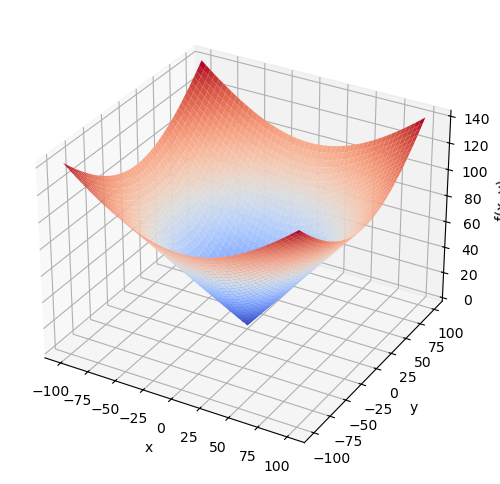

In [2]:
from matplotlib import cm

def funcion_prueba(x):
    res = np.sqrt(x[0]**2 + x[1]**2)
    return res

x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_ [x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

figure3d = plt.figure(figsize=(8, 6))
ax = figure3d.add_subplot(111, projection='3d')

ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')

In [3]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

In [4]:
creator.create("Individual", list, fitness=creator.FitnessMax)

In [5]:
toolbox = base.Toolbox()

In [6]:
# Generación de genes
toolbox.register("attr_uniform", random.uniform, -100, 100)

In [7]:
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)

In [8]:
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [9]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

In [10]:
toolbox.register("evaluate", funcion_objetivo)

In [11]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 136.77889635502862
Mejor individuo: [-9

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


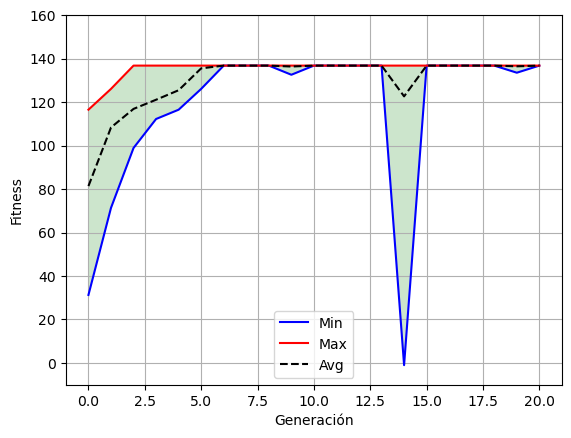

In [14]:
def main():
    random.seed(42)
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    pop = toolbox.population(n=10)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    return hof, logbook

if __name__ == "__main__":
    best, log = main()
    print(f"Mejor fitness: {best[0].fitness.values[0]}")
    print(f"Mejor individuo: {best[0]}")
    plot_evolucion(log)

In [13]:
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)
    
    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs, where=where_mask, facecolor="g", alpha=0.2)
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi=300)

# Implementacion del algoritmo para una población de 30 y 50 individuos, con 20 generaciones y tabla y grafica comparativa #

In [17]:
def implementacion(tam_poblacion):
    random.seed(42)
    np.random.seed(42)
    
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    pop = toolbox.population(n=tam_poblacion)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    
    return {
        "poblacion": tam_poblacion,
        "mejor_fitness": hof[0].fitness.values[0],
        "mejor_individuo": hof[0],
        "fitness_promedio_final": logbook.select("avg")[-1],
        "fitness_min_final": logbook.select("min")[-1],
        "fitness_max_final": logbook.select("max")[-1],
        "logbook": logbook
    }

In [19]:
res_30 = implementacion(30)
res_50 = implementacion(50)

gen	nevals	avg    	std   	min    	max    
0  	30    	77.9162	24.544	26.4289	116.497
1  	15    	98.1576	15.6516	58.7221	123.194
2  	18    	108.641	17.0172	47.071 	131.857
3  	24    	122.041	7.64215	99.9797	134.549
4  	19    	128.584	3.92487	122.005	134.549
5  	11    	132.005	2.13284	125.135	134.549
6  	22    	133.419	1.60997	131.169	136.779
7  	20    	130.449	24.4622	-1     	136.779
8  	17    	136.143	1.12918	133.455	137.464
9  	16    	136.686	0.662231	134.132	137.486
10 	14    	137.114	0.611792	136.779	139.908
11 	15    	137.235	1.30432 	131.674	139.908
12 	23    	137.979	0.981347	137.464	140.041
13 	21    	133.762	25.0534 	-1     	140.101
14 	17    	138.776	1.53284 	133.594	140.101
15 	15    	130.265	35.0922 	-1     	140.101
16 	15    	140.042	0.0666659	139.908	140.101
17 	15    	140.024	0.334088 	138.242	140.101
18 	18    	140.101	5.68434e-14	140.101	140.101
19 	20    	140.021	0.347706   	138.217	140.101
20 	20    	140.067	0.183959   	139.076	140.101
gen	nevals	avg    	std    	min   

In [22]:
tabla = pd.DataFrame([
    {
        "Población": res_30["poblacion"],
        "Mejor fitness": res_30["mejor_fitness"],
        "Fitness promedio final": res_30["fitness_promedio_final"],
        "Fitness mínimo final": res_30["fitness_min_final"],
        "Fitness máximo final": res_30["fitness_max_final"],
        "Mejor individuo": res_30["mejor_individuo"]
    },
    {
        "Población": res_50["poblacion"],
        "Mejor fitness": res_50["mejor_fitness"],
        "Fitness promedio final": res_50["fitness_promedio_final"],
        "Fitness mínimo final": res_50["fitness_min_final"],
        "Fitness máximo final": res_50["fitness_max_final"],
        "Mejor individuo": res_50["mejor_individuo"]
    }
])

tabla

,Población,Mejor fitness,Fitness promedio final,Fitness mínimo final,Fitness máximo final,Mejor individuo
0,30,140.100794,140.066634,139.075983,140.100794,"[-99.34638537370458, -98.78526358100852]"
1,50,140.676643,137.843110,-1.000000,140.676643,"[99.47519355610216, -99.47162247430336]"


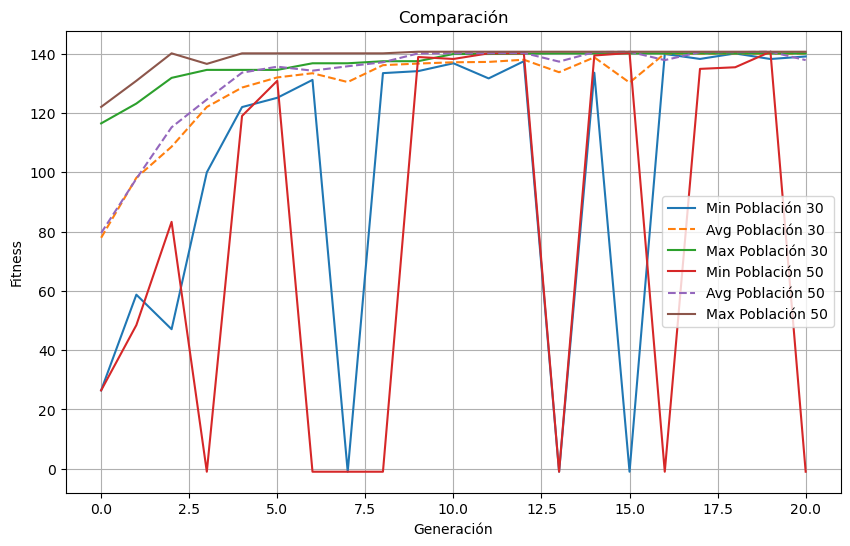

<Figure size 640x480 with 0 Axes>

In [28]:
def grafica_comparativa(log1, log2, label1, label2):
    gen1 = np.array(log1.select("gen"))
    min1 = np.array(log1.select("min"), dtype=float)
    avg1 = np.array(log1.select("avg"), dtype=float)
    max1 = np.array(log1.select("max"), dtype=float)

    gen2 = np.array(log2.select("gen"))
    min2 = np.array(log2.select("min"), dtype=float)
    avg2 = np.array(log2.select("avg"), dtype=float)
    max2 = np.array(log2.select("max"), dtype=float)

    plt.figure(figsize=(10, 6))
    
    plt.plot(gen1, min1, label=f"Min {label1}")
    plt.plot(gen1, avg1, linestyle="--", label=f"Avg {label1}")
    plt.plot(gen1, max1, label=f"Max {label1}")
    
    plt.plot(gen2, min2, label=f"Min {label2}")
    plt.plot(gen2, avg2, linestyle="--", label=f"Avg {label2}")
    plt.plot(gen2, max2, label=f"Max {label2}")
    
    plt.xlabel("Generación")
    plt.ylabel("Fitness")
    plt.title("Comparación")
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.savefig("Comparacion.eps", dpi=300)

grafica_comparativa(
    res_30["logbook"],
    res_50["logbook"],
    "Población 30",
    "Población 50"
)